# Load statistics and plot mean + 16-84 percentile ranges

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import sys
import os

_scripts = Path.cwd() / "scripts"
if not _scripts.exists():
    _scripts = Path.cwd().parent / "scripts"
sys.path.insert(0, str(_scripts.resolve()))

import data_loader
import utils

%load_ext autoreload
%autoreload 2

2026-03-18 01:33:47.365324: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-18 01:33:47.477471: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-18 01:33:47.477514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-18 01:33:47.492584: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-18 01:33:47.527038: I tensorflow/core/platform/cpu_feature_guar

## Config

In [20]:
n_cosmo_max = 100

tag_params_train = '_p5_n10000'
tag_params_coverage = '_coverage_p5_n1000'
tag_params_shame_p0 = '_shame_p0_n1000'
tag_mock_shame = '_nbar0.00022'

tag_biasparams_fixed = '_biasshame_p0_n1'
tag_biasparams_fixed_bl0 = '_biasshamebl0_p0_n1'
tag_biasparams_nest = '_biasnest_p4_n320000'
tag_biasparams_cov = '_biascoverage_p4_n1000'

bias_param_cols = ['b1', 'b2', 'bs2', 'bl']

param_dict_shame = data_loader.load_params_ood('shame', tag_mock_shame)
bias_vector_shame = [param_dict_shame[name] for name in utils.biasparam_names_ordered]
print('Shame bias params:', dict(zip(utils.biasparam_names_ordered, bias_vector_shame)))


def stats_summary(arr):
    return (np.nanmean(arr, axis=0),
            np.nanpercentile(arr, 16, axis=0),
            np.nanpercentile(arr, 84, axis=0))


def plot_fill(ax, x, mean, p16, p84, color, label):
    ax.fill_between(x, p16, p84, color=color, alpha=0.3, label=f'{label} (16-84%)')
    ax.plot(x, mean, color=color, label=f'{label} (mean)')


def plot_fill_hatch(ax, x, mean, p16, p84, color, label):
    """Same color as plot_fill but dashed mean and cross-hatch for 16-84% band."""
    ax.fill_between(x, p16, p84, color=color, alpha=0.25, hatch='xx', label=f'{label} (16-84%)')
    ax.plot(x, mean, color=color, linestyle='--', label=f'{label} (mean)')


def format_ax(ax, title, xlabel, ylabel, xlog=True, ylog=True):
    if xlog:
        ax.set_xscale('log')
    if ylog:
        ax.set_yscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(loc='best', fontsize=8)
    ax.set_title(title)

Shame bias params: {'b1': 0.47410742, 'b2': 0.12701492, 'bs2': -0.33881766, 'bl': -0.82443643}


## Check nested bias params

In [3]:
fn_nest_params = '../data/params/params_lh_biasnest_p4_n320000.txt'
df_nest = pd.read_csv(fn_nest_params, index_col=0)
print(f"Shape: {df_nest.shape}")
print(f"Columns: {df_nest.columns.tolist()}")
print(f"\nFirst 10 rows:")
df_nest.head(10)

Shape: (320000, 6)
Columns: ['b1', 'b2', 'bs2', 'bl', 'idx_cosmo', 'nest_layer']

First 10 rows:


,b1,b2,bs2,bl,idx_cosmo,nest_layer
0,-0.410989,-1.639792,1.339203,-3.902996,0,0
1,2.626207,1.480202,1.150603,6.707007,1,0
2,-0.084996,-1.894388,1.278801,-2.257958,2,0
3,1.867210,-0.830590,-1.893995,-6.559939,3,0
4,0.276207,-0.861799,-1.481599,1.676001,4,0
5,0.170010,-0.322197,0.846001,-8.614969,5,0
6,0.516006,0.437403,1.319809,-1.120948,6,0
7,0.470004,-0.954791,1.993212,1.246019,7,0
8,-0.119195,-1.729792,-0.589590,-6.786964,8,0
9,2.195610,-0.367798,-1.875194,4.209050,9,0


In [4]:
expected_bounds = {
    'b1':  [-1.0, 3.0],
    'b2':  [-2.0, 2.0],
    'bs2': [-2.0, 2.0],
    'bl':  [-10.0, 10.0],
}

print("Bounds check:")
for col in bias_param_cols:
    lo, hi = expected_bounds[col]
    actual_min, actual_max = df_nest[col].min(), df_nest[col].max()
    within = (actual_min >= lo) and (actual_max <= hi)
    covers = (actual_max - actual_min) > 0.99 * (hi - lo)
    status = "PASS" if (within and covers) else "FAIL"
    print(f"  {col:4s}: [{actual_min:+.6f}, {actual_max:+.6f}]  expected [{lo}, {hi}]  "
          f"within={within}  covers_99%={covers}  {status}")
    assert within, f"{col} outside expected bounds!"
    assert covers, f"{col} does not cover at least 99% of expected range!"

print("\nAll bounds checks passed.")
print("\nBasic stats:")
df_nest[bias_param_cols].describe()

Bounds check:
  b1  : [-1.000000, +2.999997]  expected [-1.0, 3.0]  within=True  covers_99%=True  PASS
  b2  : [-1.999990, +1.999998]  expected [-2.0, 2.0]  within=True  covers_99%=True  PASS
  bs2 : [-1.999998, +1.999990]  expected [-2.0, 2.0]  within=True  covers_99%=True  PASS
  bl  : [-9.999949, +9.999963]  expected [-10.0, 10.0]  within=True  covers_99%=True  PASS

All bounds checks passed.

Basic stats:


,b1,b2,bs2,bl
count,320000.000000,3.200000e+05,3.200000e+05,3.200000e+05
mean,1.000000,8.395680e-10,7.511721e-09,-1.477290e-08
std,1.154702,1.154702e+00,1.154702e+00,5.773512e+00
min,-1.000000,-1.999990e+00,-1.999998e+00,-9.999949e+00
25%,0.000004,-9.999995e-01,-9.999940e-01,-5.000007e+00
50%,1.000000,-1.296251e-06,2.831097e-06,1.392974e-05
75%,1.999996,9.999984e-01,9.999945e-01,4.999980e+00
max,2.999997,1.999998e+00,1.999990e+00,9.999963e+00


In [5]:
print("Metadata:")
print(f"  idx_cosmo unique values: {df_nest['idx_cosmo'].nunique()} (expect 10000)")
print(f"  idx_cosmo range: [{df_nest['idx_cosmo'].min()}, {df_nest['idx_cosmo'].max()}]")
print(f"  nest_layer unique values: {sorted(df_nest['nest_layer'].unique())}")
print(f"\n  Rows per nest_layer:")
print(df_nest['nest_layer'].value_counts().sort_index())
print(f"\n  Rows per cosmo (should all be 32):")
cosmo_counts = df_nest['idx_cosmo'].value_counts()
print(f"    min: {cosmo_counts.min()}, max: {cosmo_counts.max()}, mean: {cosmo_counts.mean():.1f}")

Metadata:
  idx_cosmo unique values: 10000 (expect 10000)
  idx_cosmo range: [0, 9999]
  nest_layer unique values: [0, 1, 2, 3, 4, 5]

  Rows per nest_layer:
nest_layer
0     10000
1     10000
2     20000
3     40000
4     80000
5    160000
Name: count, dtype: int64

  Rows per cosmo (should all be 32):
    min: 32, max: 32, mean: 32.0


In [6]:
n_cosmo = 10000
n_factors = [1, 2, 4, 8, 16, 32]
print("Nesting check (cumulative rows per layer):")
for j in range(len(n_factors)):
    subset = df_nest[df_nest['nest_layer'] <= j]
    expected = n_cosmo * n_factors[j]
    print(f"  nest_layer <= {j}: {len(subset)} rows (expected {expected}, factor={n_factors[j]}x)")

print("\nNesting of cosmo sets:")
for j in range(len(n_factors) - 1):
    set_j = set(zip(df_nest[df_nest['nest_layer'] <= j].index,
                     df_nest[df_nest['nest_layer'] <= j]['idx_cosmo']))
    set_j1 = set(zip(df_nest[df_nest['nest_layer'] <= j+1].index,
                      df_nest[df_nest['nest_layer'] <= j+1]['idx_cosmo']))
    print(f"  layer<={j} subset of layer<={j+1}: {set_j.issubset(set_j1)}")

Nesting check (cumulative rows per layer):
  nest_layer <= 0: 10000 rows (expected 10000, factor=1x)
  nest_layer <= 1: 20000 rows (expected 20000, factor=2x)
  nest_layer <= 2: 40000 rows (expected 40000, factor=4x)
  nest_layer <= 3: 80000 rows (expected 80000, factor=8x)
  nest_layer <= 4: 160000 rows (expected 160000, factor=16x)
  nest_layer <= 5: 320000 rows (expected 320000, factor=32x)

Nesting of cosmo sets:
  layer<=0 subset of layer<=1: True
  layer<=1 subset of layer<=2: True
  layer<=2 subset of layer<=3: True
  layer<=3 subset of layer<=4: True
  layer<=4 subset of layer<=5: True


# Noiseless

## PNN

In [7]:
# Training: fixed bias (shame bias on all cosmologies)
k_pnn_train_fixed, pks_train_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_train, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pnn_tf, p16_pnn_tf, p84_pnn_tf = stats_summary(pks_train_fixed)
print(f"Training fixed bias: {pks_train_fixed.shape}")

# Training: varying bias (nested, all 32 layers)
k_pnn_train_vary, pks_train_vary, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_train, tag_biasparams_nest, n_cosmo_max=n_cosmo_max)
mean_pnn_tv, p16_pnn_tv, p84_pnn_tv = stats_summary(pks_train_vary)
print(f"Training varying bias: {pks_train_vary.shape}")

# Coverage: fixed bias
k_pnn_cov_fixed, pks_cov_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_coverage, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pnn_cf, p16_pnn_cf, p84_pnn_cf = stats_summary(pks_cov_fixed)
print(f"Coverage fixed bias: {pks_cov_fixed.shape}")

# Coverage: varying bias (biascoverage)
k_pnn_cov_vary, pks_cov_vary, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_coverage, tag_biasparams_cov, n_cosmo_max=n_cosmo_max)
mean_pnn_cv, p16_pnn_cv, p84_pnn_cv = stats_summary(pks_cov_vary)
print(f"Coverage varying bias: {pks_cov_vary.shape}")

# Fixed cosmology (shame_p0)
k_pnn_shame, pks_shame_p0, _, _ = data_loader.load_data_muchisimocks(
    'pk', tag_params_shame_p0, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pnn_sp, p16_pnn_sp, p84_pnn_sp = stats_summary(pks_shame_p0)
print(f"Fixed cosmology: {pks_shame_p0.shape}")

# SHAMe mock PK
k_shame_pk, y_shame_pk, _ = data_loader.load_data_shame('pk', tag_mock_shame)

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training fixed bias: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_p5_n10000_biasnest_p4_n320000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias: (3200, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_coverage_p5_n1000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_cover

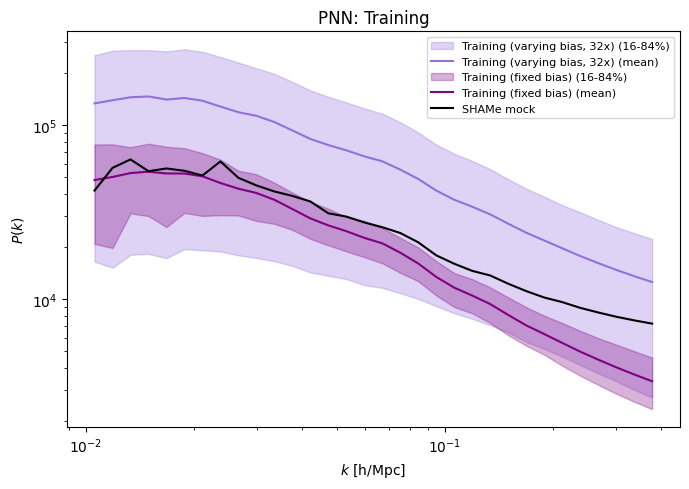

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pnn_train_vary, mean_pnn_tv, p16_pnn_tv, p84_pnn_tv,
          'mediumpurple', 'Training (varying bias, 32x)')
plot_fill(ax, k_pnn_train_fixed, mean_pnn_tf, p16_pnn_tf, p84_pnn_tf,
          'purple', 'Training (fixed bias)')
ax.plot(k_shame_pk, y_shame_pk, color='black', label='SHAMe mock')
format_ax(ax, 'PNN: Training', r'$k$ [h/Mpc]', r'$P(k)$')
plt.tight_layout()
plt.show()

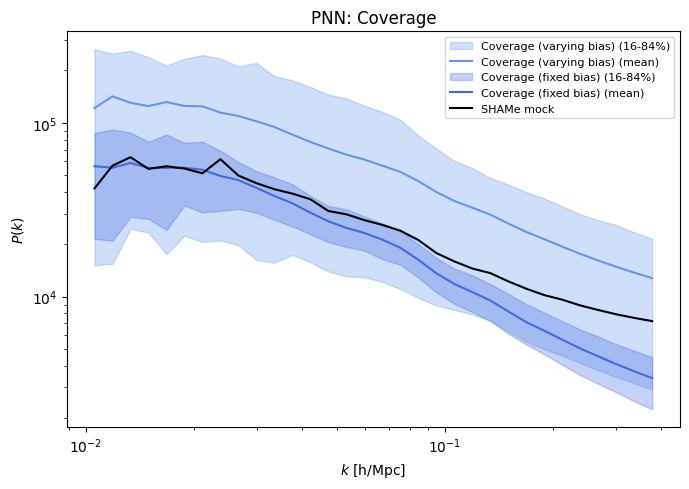

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pnn_cov_vary, mean_pnn_cv, p16_pnn_cv, p84_pnn_cv,
          'cornflowerblue', 'Coverage (varying bias)')
plot_fill(ax, k_pnn_cov_fixed, mean_pnn_cf, p16_pnn_cf, p84_pnn_cf,
          'royalblue', 'Coverage (fixed bias)')
ax.plot(k_shame_pk, y_shame_pk, color='black', label='SHAMe mock')
format_ax(ax, 'PNN: Coverage', r'$k$ [h/Mpc]', r'$P(k)$')
plt.tight_layout()
plt.show()

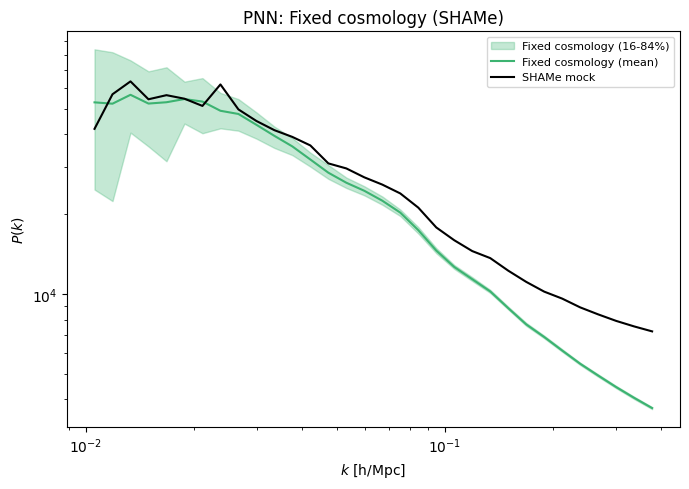

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pnn_shame, mean_pnn_sp, p16_pnn_sp, p84_pnn_sp,
          'mediumseagreen', 'Fixed cosmology')
ax.plot(k_shame_pk, y_shame_pk, color='black', label='SHAMe mock')
format_ax(ax, 'PNN: Fixed cosmology (SHAMe)', r'$k$ [h/Mpc]', r'$P(k)$')
plt.tight_layout()
plt.show()

## PGM

In [21]:
# Training: fixed bias (PGM from PNNs with shame bias, or precomputed if available)
k_pgm_train_fixed, pgms_train_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_train, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pgm_tf, p16_pgm_tf, p84_pgm_tf = stats_summary(pgms_train_fixed)
print(f"Training fixed bias PGM: {pgms_train_fixed.shape}")

# Training: varying bias (precomputed, bx=1)
k_pgm_train_vary, pgms_train_vary, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_train, tag_biasparams_nest, bx=1, n_cosmo_max=n_cosmo_max)
mean_pgm_tv, p16_pgm_tv, p84_pgm_tv = stats_summary(pgms_train_vary)
print(f"Training varying bias PGM: {pgms_train_vary.shape}")

# Coverage: fixed bias (PGM from PNNs with shame bias, or precomputed if available)
k_pgm_cov_fixed, pgms_cov_fixed, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_coverage, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pgm_cf, p16_pgm_cf, p84_pgm_cf = stats_summary(pgms_cov_fixed)
print(f"Coverage fixed bias PGM: {pgms_cov_fixed.shape}")

# Coverage: varying bias (precomputed)
k_pgm_cov_vary, pgms_cov_vary, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_coverage, tag_biasparams_cov, n_cosmo_max=n_cosmo_max)
mean_pgm_cv, p16_pgm_cv, p84_pgm_cv = stats_summary(pgms_cov_vary)
print(f"Coverage varying bias PGM: {pgms_cov_vary.shape}")

# Fixed cosmology (precomputed)
k_pgm_shame, pgms_shame_p0, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_shame_p0, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_pgm_sp, p16_pgm_sp, p84_pgm_sp = stats_summary(pgms_shame_p0)
print(f"Fixed cosmology PGM: {pgms_shame_p0.shape}")

# Fixed cosmology with bl=0 (recombine PNNs into PGMs via tag_biasparams_fixed_bl0)
_, pgms_shame_p0_bl0, _, _ = data_loader.load_data_muchisimocks(
    'pgm', tag_params_shame_p0, tag_biasparams_fixed_bl0, n_cosmo_max=n_cosmo_max)
mean_pgm_sp_bl0, p16_pgm_sp_bl0, p84_pgm_sp_bl0 = stats_summary(pgms_shame_p0_bl0)
print(f"Fixed cosmology PGM (bl=0): {pgms_shame_p0_bl0.shape}")

# SHAMe mock PGM
k_shame_pgm, y_shame_pgm, _ = data_loader.load_data_shame('pgm', tag_mock_shame)

dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training fixed bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_p5_n10000_biasnest_p4_n320000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000


Found 10000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_p5_n10000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_coverage_p5_n1000_biasshame_p0_n1
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage fixed bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_coverage_p5_n1000_biascoverage_p4_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Found 1000 diff cosmo pnns in /scratch/kstoreyf/muchisimocks/data/pnns_mlib/pnns_coverage_p5_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage varying bias PGM: (100, 32)
dir_statistics: /scratch/kstoreyf/muchisimocks/da

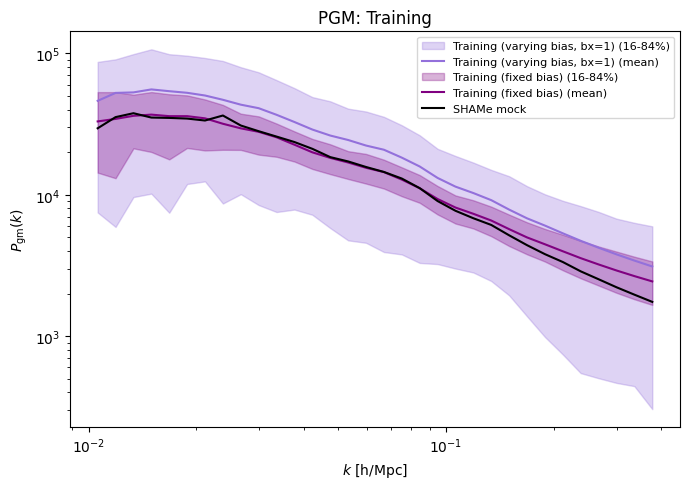

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pgm_train_vary, mean_pgm_tv, p16_pgm_tv, p84_pgm_tv,
          'mediumpurple', 'Training (varying bias, bx=1)')
plot_fill(ax, k_pgm_train_fixed, mean_pgm_tf, p16_pgm_tf, p84_pgm_tf,
          'purple', 'Training (fixed bias)')
ax.plot(k_shame_pgm, y_shame_pgm, color='black', label='SHAMe mock')
format_ax(ax, 'PGM: Training', r'$k$ [h/Mpc]', r'$P_\mathrm{gm}(k)$')
plt.tight_layout()
plt.show()

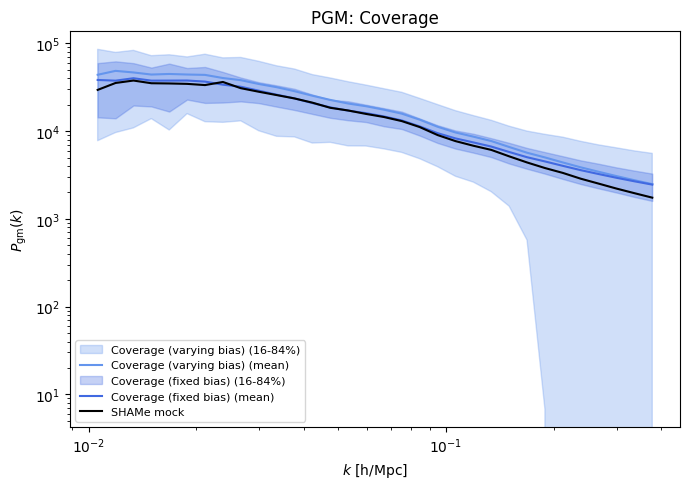

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pgm_cov_vary, mean_pgm_cv, p16_pgm_cv, p84_pgm_cv,
          'cornflowerblue', 'Coverage (varying bias)')
plot_fill(ax, k_pgm_cov_fixed, mean_pgm_cf, p16_pgm_cf, p84_pgm_cf,
          'royalblue', 'Coverage (fixed bias)')
ax.plot(k_shame_pgm, y_shame_pgm, color='black', label='SHAMe mock')
format_ax(ax, 'PGM: Coverage', r'$k$ [h/Mpc]', r'$P_\mathrm{gm}(k)$')
plt.tight_layout()
plt.show()

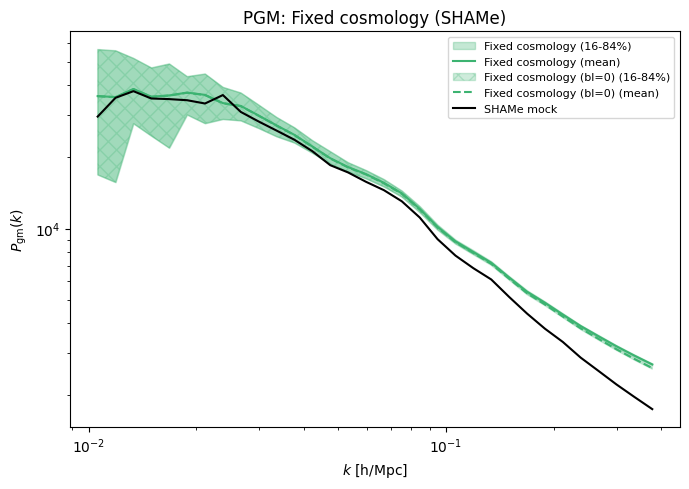

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, k_pgm_shame, mean_pgm_sp, p16_pgm_sp, p84_pgm_sp,
          'mediumseagreen', 'Fixed cosmology')
plot_fill_hatch(ax, k_pgm_shame, mean_pgm_sp_bl0, p16_pgm_sp_bl0, p84_pgm_sp_bl0,
                'mediumseagreen', 'Fixed cosmology (bl=0)')
ax.plot(k_shame_pgm, y_shame_pgm, color='black', label='SHAMe mock')
format_ax(ax, 'PGM: Fixed cosmology (SHAMe)', r'$k$ [h/Mpc]', r'$P_\mathrm{gm}(k)$')
plt.tight_layout()
plt.show()

## Bispectrum

For the bispectrum, we only have precomputed (unlike pnn case) that we have only run on the varying set, so don't have the fixed versions (which are free to get in the pnn and pgm cases as we can just recombine the pnns)

In [15]:
# Training: varying bias (precomputed, bx=1)
k_bispec_train_vary, bispec_train_vary, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_train, tag_biasparams_nest, bx=1, n_cosmo_max=n_cosmo_max)
mean_bispec_tv, p16_bispec_tv, p84_bispec_tv = stats_summary(bispec_train_vary)
print(f"Training varying bias bispec: {bispec_train_vary.shape}")

# Coverage: varying bias (precomputed)
k_bispec_cov_vary, bispec_cov_vary, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_coverage, tag_biasparams_cov, n_cosmo_max=n_cosmo_max)
mean_bispec_cv, p16_bispec_cv, p84_bispec_cv = stats_summary(bispec_cov_vary)
print(f"Coverage varying bias bispec: {bispec_cov_vary.shape}")

# Fixed cosmology (precomputed)
k_bispec_shame, bispec_shame_p0, _, _ = data_loader.load_data_muchisimocks(
    'bispec', tag_params_shame_p0, tag_biasparams_fixed, n_cosmo_max=n_cosmo_max)
mean_bispec_sp, p16_bispec_sp, p84_bispec_sp = stats_summary(bispec_shame_p0)
print(f"Fixed cosmology bispec: {bispec_shame_p0.shape}")

# SHAMe mock bispectrum
k_shame_bispec, y_shame_bispec, _ = data_loader.load_data_shame('bispec', tag_mock_shame)

dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnest_p4_n320000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnest_p4_n320000
Found 9305 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_p5_n10000_biasnest_p4_n320000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Training varying bias bispec: (100, 203)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Loading muchisimocks data from /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Found 1000 diff cosmo bispecs in /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_coverage_p5_n1000_biascoverage_p4_n1000
Subsampled to 100 cosmologies (n_cosmo_max=100)
Coverage varying bias bispec: (100, 203)
dir_statistics: /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_shame_p0_n1000_biasshame_p0_n1
Loadin

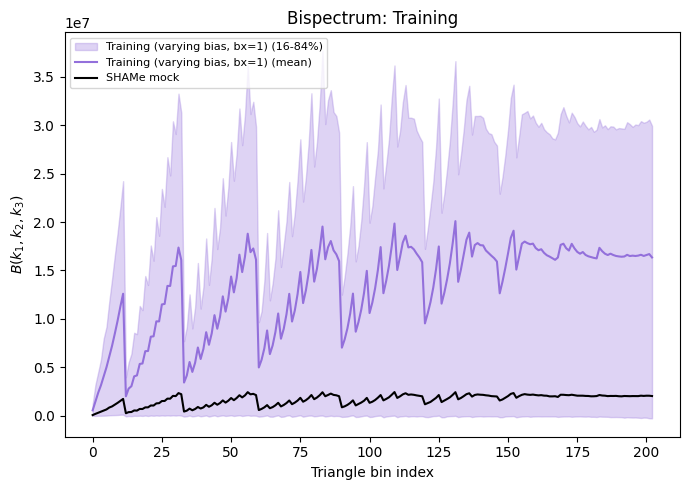

In [16]:
x_bispec = np.arange(len(mean_bispec_tv))
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, x_bispec, mean_bispec_tv, p16_bispec_tv, p84_bispec_tv,
          'mediumpurple', 'Training (varying bias, bx=1)')
ax.plot(np.arange(len(y_shame_bispec)), y_shame_bispec, color='black', label='SHAMe mock')
format_ax(ax, 'Bispectrum: Training', 'Triangle bin index', r'$B(k_1, k_2, k_3)$',
          xlog=False, ylog=False)
plt.tight_layout()
plt.show()

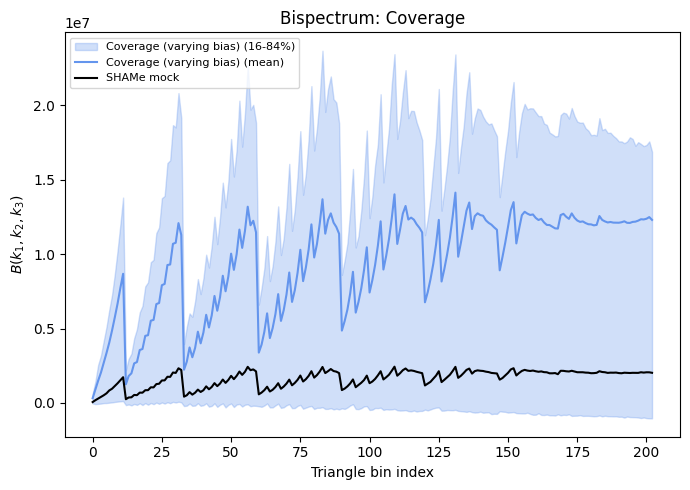

In [17]:
x_bispec_cov = np.arange(len(mean_bispec_cv))
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, x_bispec_cov, mean_bispec_cv, p16_bispec_cv, p84_bispec_cv,
          'cornflowerblue', 'Coverage (varying bias)')
ax.plot(np.arange(len(y_shame_bispec)), y_shame_bispec, color='black', label='SHAMe mock')
format_ax(ax, 'Bispectrum: Coverage', 'Triangle bin index', r'$B(k_1, k_2, k_3)$',
          xlog=False, ylog=False)
plt.tight_layout()
plt.show()

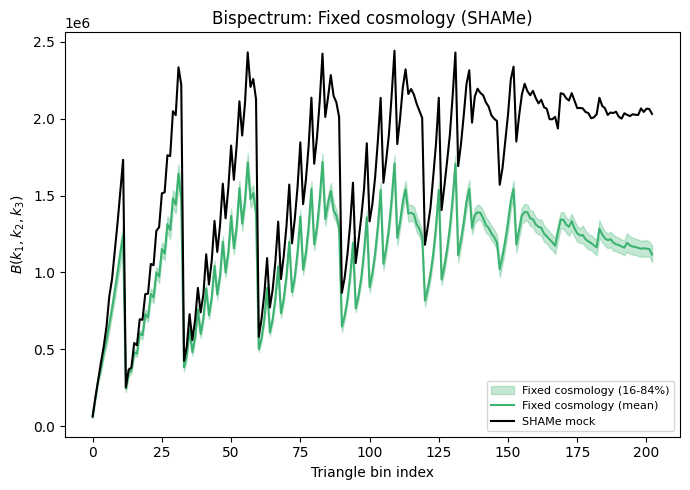

In [18]:
x_bispec_sp = np.arange(len(mean_bispec_sp))
fig, ax = plt.subplots(figsize=(7, 5))
plot_fill(ax, x_bispec_sp, mean_bispec_sp, p16_bispec_sp, p84_bispec_sp,
          'mediumseagreen', 'Fixed cosmology')
ax.plot(np.arange(len(y_shame_bispec)), y_shame_bispec, color='black', label='SHAMe mock')
format_ax(ax, 'Bispectrum: Fixed cosmology (SHAMe)', 'Triangle bin index', r'$B(k_1, k_2, k_3)$',
          xlog=False, ylog=False)
plt.tight_layout()
plt.show()